# **Импорт важных библиотек**


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

from sklearn.manifold import TSNE

from sklearn.model_selection import StratifiedKFold

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split

import plotly.express as px


In [ ]:
plt.style.use('dark_background')

# **Набор данных MNIST**

В качестве данных будем использовать изображения чисел от 0 до 9

Мы используем функцию fetch_openml для загрузки данных с сайта [OpenML](https://www.openml.org/search?type=data), используя имя набора данных **'mnist_784'**

In [ ]:
X, y  = fetch_openml('mnist_784',
                     version=1,
                     return_X_y=True,
                     parser='auto')
# нормализуем, так как изображения имеют значения от 0 до 255
X = X / 255
X.shape

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


(70000, 784)

В этом наборе данных 70000 примеров

И 784 параметра (упорядочены так, чтобы получилось изображение 28 на 28)

In [ ]:
X_part,y_part = X.values [:2500], y[:2500].astype(int).values

In [ ]:
#@title Гиперпараметры T-SNE { run: "auto" }
n_iter = 1000 #@param {type:"slider", min:250, max:1500, step:25}
perplexity = 25 #@param {type:"slider", min:5, max:50, step:5}

tsne = TSNE(n_components=2, verbose=1,
            perplexity=perplexity, n_iter=n_iter,
            learning_rate = 'auto', init = 'pca')
tsne_results = tsne.fit_transform(X_part)


[t-SNE] Computing 76 nearest neighbors...
[t-SNE] Indexed 2500 samples in 0.010s...
[t-SNE] Computed neighbors for 2500 samples in 0.383s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2500
[t-SNE] Computed conditional probabilities for sample 2000 / 2500
[t-SNE] Computed conditional probabilities for sample 2500 / 2500
[t-SNE] Mean sigma: 2.371464
[t-SNE] KL divergence after 250 iterations with early exaggeration: 78.143188
[t-SNE] KL divergence after 1000 iterations: 1.238676


Визуализация

In [ ]:
def plot_data_multy(ax,ds,name=''):
    X, y = ds

    ax.set_title(name)

    for i in range(X.shape[0]):
      plt.text(X[i, 0], X[i, 1], str(y[i]),
                color=plt.cm.tab10((y[i]+0.5) /10 ),
                fontdict={'weight': 'bold', 'size': 9})


    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())

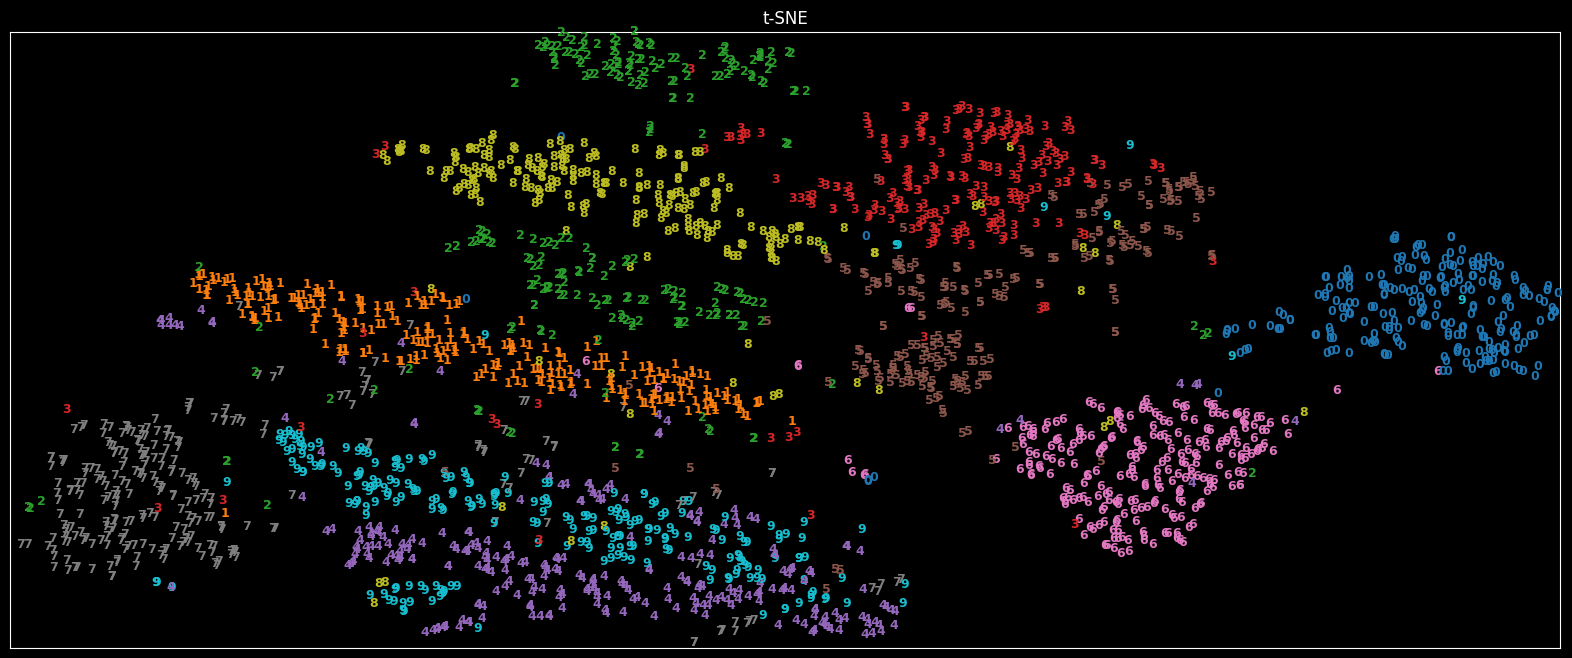

In [ ]:
fig= plt.figure(figsize=(20,12))
ax = plt.subplot(1, 1, 1)
plot_data_multy(ax,[tsne_results,y_part],'t-SNE')

Ну, или интерактивная версия

In [ ]:
df = pd.DataFrame(tsne_results, columns = ['t-SNE_1', 't-SNE_2'])
df['number'] = y_part.astype(str)

In [ ]:
fig = px.scatter(
        df,
        x='t-SNE_1', y='t-SNE_2',
             color = 'number',
        labels={'color': 'number'},
        hover_data=[df.index]
)


fig.update_layout(
    height=800,
    width=1500,
    template = "plotly_dark"
)

fig.update_traces(textposition='top center')

fig.show()

Выделим некоторые "спорные" индексы

In [ ]:
shady_figs = [1097, # 3 среди 2
              1137, # 0 среди 8
              2098, # 3 среди 7
              916, # 5 в центре 6
              850, # 4 среди тех же 6
              420, # 5 среди 9
              902, # 9 среди 0
              1276, 670,# 3 и 5 - два "брата"
              494 # 6 среди 0
              ]

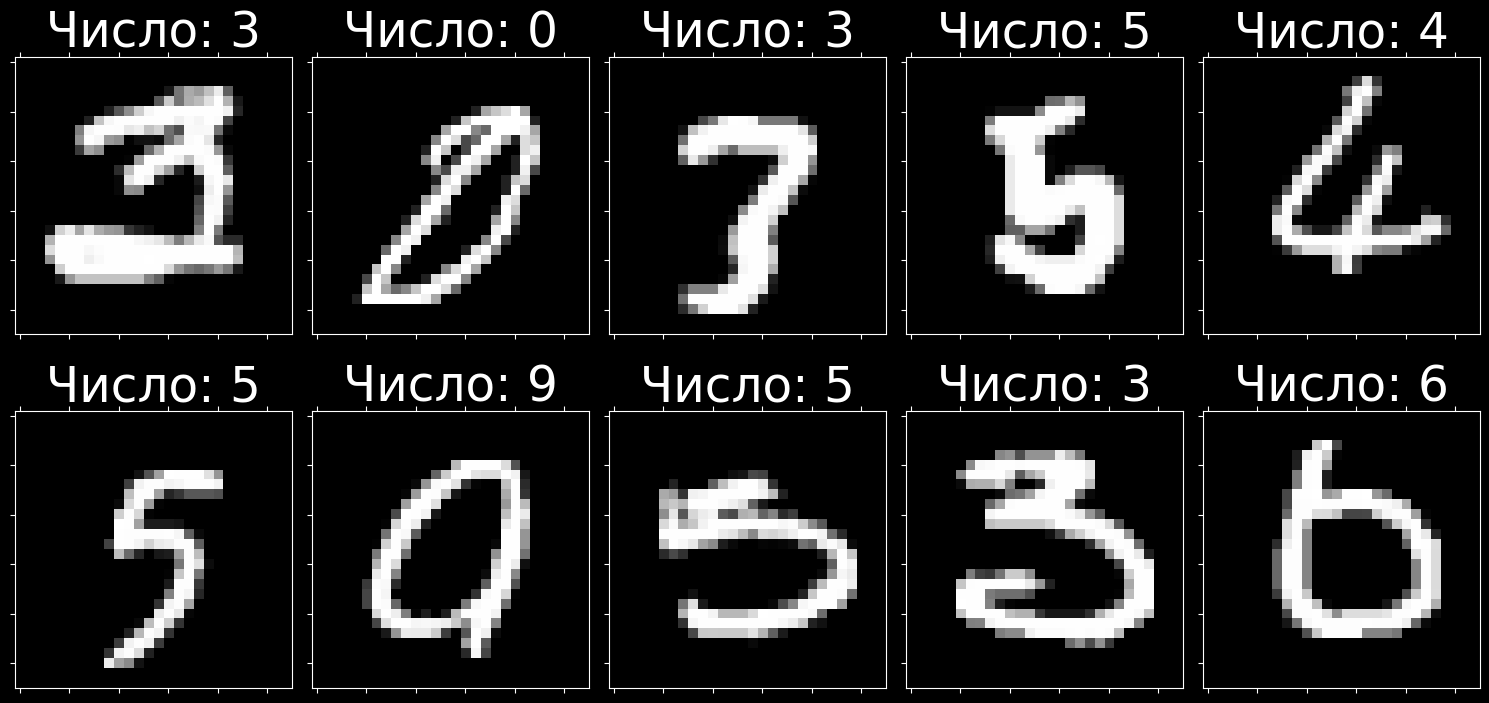

In [ ]:
# создаем полотно
fig = plt.figure( figsize=(15,8) )
# на котором визуализируем 10 примеров изображений
# начиная с индекса n
for n, i in enumerate(shady_figs):
    # каждое изображение будет на своем сабплоте
    ax = fig.add_subplot(2,5,n+1)
    # пишем какое число должно быть
    ax.set_title("Число: {}".format(str(y[i]) ), size=35)
    # отрисовываем с помощью функции matshow
    # для этого нам вектор-строку из 784 элементов
    # нужно преобразовать в матрицу 28 на 28
    ax.matshow(1-X.loc[i,'pixel1':'pixel784'].values.reshape((28,28)).astype(float),
                cmap='Greys')
    plt.setp(ax.get_xticklabels(), visible=False)
    plt.setp(ax.get_yticklabels(), visible=False)
    plt.tight_layout()